<a href="https://colab.research.google.com/github/DenisaEM/ProiectIA-/blob/main/ProiectIA_ZOO_with_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import the Zoo dataset from UCI Machine Learning Library**

Method 1

In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset using its ID
zoo = fetch_ucirepo(id=111)

# Data (as pandas dataframes)
X = zoo.data.features
y = zoo.data.targets

# Metadata & Variable Information
print(zoo.metadata)
print(zoo.variables)

# Features & targets
print(X)
print(y)

Method 2

In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data"

column_names = ['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone',
                 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'type']

zoo = pd.read_csv(url, names = column_names)
print(zoo.head)

# **Using an alternative solution to download the dataset since UCI server and API are giving "502 Bad Gateway Error"**

To import the data I used the code snippet provided by Kaggle, where it is an official copy of the dataset made by UCI.

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "zoo.csv"
class_description = "class.csv"

# Load the latest version
zoo = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"uciml/zoo-animal-classification",file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
classes = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"uciml/zoo-animal-classification",class_description)

print(zoo)
print(classes)

Using Colab cache for faster access to the 'zoo-animal-classification' dataset.
Using Colab cache for faster access to the 'zoo-animal-classification' dataset.
    animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0      aardvark     1         0     0     1         0        0         1   
1      antelope     1         0     0     1         0        0         0   
2          bass     0         0     1     0         0        1         1   
3          bear     1         0     0     1         0        0         1   
4          boar     1         0     0     1         0        0         1   
..          ...   ...       ...   ...   ...       ...      ...       ...   
96      wallaby     1         0     0     1         0        0         0   
97         wasp     1         0     1     0         1        0         0   
98         wolf     1         0     0     1         0        0         1   
99         worm     0         0     1     0         0        0         0   
100 

# **Pre-processing the data**

**Data Quality**

In [2]:
'''
First we verify if there are any duplicates.
Remove the column with the animal_name because we don't need it for the analysis. Also, we remove the last column because
that is what we want to predict.
'''

# Check for duplicate animal names
duplicates = zoo['animal_name'].duplicated().sum()
print(f"Number of duplicate names: {duplicates}")

# Since there are duplicates we want to keep only the first instance an animal appears
zoo_cleaned = zoo.drop_duplicates(subset='animal_name', keep='first')

# Reset the index so it goes from 0 to 99
zoo_cleaned = zoo_cleaned.reset_index(drop=True)

# Now check the last few rows
print(zoo_cleaned.tail())

# y represents what we want to find, X is the list of features, we remove the animal name column and class_type
X = zoo_cleaned.drop(columns=['animal_name', 'class_type'])
y = zoo_cleaned['class_type']

# Print first 5 rows
print(X.head())
print(y.head())

Number of duplicate names: 1
   animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
95     wallaby     1         0     0     1         0        0         0   
96        wasp     1         0     1     0         1        0         0   
97        wolf     1         0     0     1         0        0         1   
98        worm     0         0     1     0         0        0         0   
99        wren     0         1     1     0         1        0         0   

    toothed  backbone  breathes  venomous  fins  legs  tail  domestic  \
95        1         1         1         0     0     2     1         0   
96        0         0         1         1     0     6     0         0   
97        1         1         1         0     0     4     1         0   
98        0         0         1         0     0     0     0         0   
99        0         1         1         0     0     2     1         0   

    catsize  class_type  
95        1           1  
96        0           6  
97 

## Import Library

In [3]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
import seaborn as sns
from sklearn import svm
import pandas as pd

**Separate data train and test sets.**
 It can be observed in the original dataset that mammals have 41 instances, while classes like Amphibian and Reptile have 4, respectively 5 instances. Since we cleaned the data, and now we have 100 animals in the dataset, we want to avoid the case in which there will be no data train for classes with less animals. We make sure to keep a good 75%-25% ratio by stratifying the data.

In [4]:
from sklearn.model_selection import train_test_split

# Separate data in training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 75
Testing set size: 25


**Method 1: Using the algorithm with the clean data unscaled and without duplicates**

In [5]:

from sklearn.metrics import accuracy_score, classification_report

clf=svm.SVC(kernel='rbf',C=1,gamma='scale')
clf.fit(X_train,y_train)
predictie_unscaled=clf.predict(X_test)

# See the results
print(f"Accuracy: {accuracy_score(y_test, predictie_unscaled) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, predictie_unscaled, zero_division=0))

Accuracy: 92.00%

Classification Report:
              precision    recall  f1-score   support

           1       0.91      1.00      0.95        10
           2       1.00      1.00      1.00         5
           3       0.00      0.00      0.00         1
           4       0.75      1.00      0.86         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.92        25
   macro avg       0.67      0.71      0.69        25
weighted avg       0.85      0.92      0.88        25



Create a confusion matrix

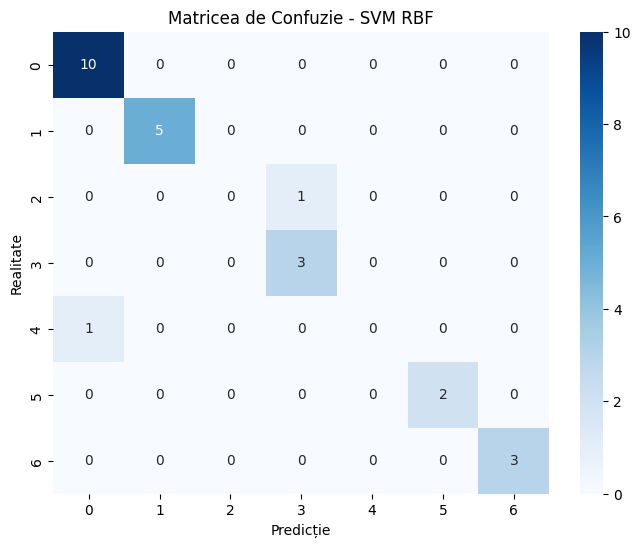

In [6]:
from sklearn.metrics import confusion_matrix

# Calculating the confusion matrix
cm = confusion_matrix(y_test, predictie_unscaled)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - SVM RBF')
plt.show()

We see in the confusion matrix that one animal from class 4 was incorectly classified and one animal from class 3. First we need to find which index is for that animal. After that we check which animal that is in the cleaned dataset.

In [7]:
# Check what animal was incorectly clasified
for index in range(len(y_test)):
  if y_test.iloc[index] != predictie_unscaled[index]:
        # Get the actual index label from y_test
        original_animal_index = y_test.index[index]
        print(f"Predicted: {predictie_unscaled[index]}, Real: {y_test.iloc[index]}")
        print(f"Predicted class: {classes.iloc[predictie_unscaled[index]-1]['Class_Type']}, Real class: {classes.iloc[y_test.iloc[index]-1]['Class_Type']}")
        print(f"Animal:")
        display(zoo_cleaned.loc[original_animal_index].to_frame().T)

Predicted: 4, Real: 3
Predicted class: Fish, Real class: Reptile
Animal:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
79,slowworm,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,3


Predicted: 1, Real: 5
Predicted class: Mammal, Real class: Amphibian
Animal:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5


**Method 2: Same algortihm with scaled data and without duplicates**

In [8]:
from sklearn.preprocessing import StandardScaler
# Scale the data because the number of legs can confuse the algorithm being higher than the data in other columns
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [9]:
from sklearn.metrics import accuracy_score, classification_report

model=svm.SVC(kernel='rbf',C=1,gamma='scale')
model.fit(X_train_scaled,y_train)
predictie_scaled = model.predict(X_test_scaled)

# See the results
print(f"Accuracy: {accuracy_score(y_test, predictie_scaled) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, predictie_scaled, zero_division=0))

Accuracy: 96.00%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         5
           3       0.50      1.00      0.67         1
           4       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.96        25
   macro avg       0.79      0.86      0.81        25
weighted avg       0.94      0.96      0.95        25



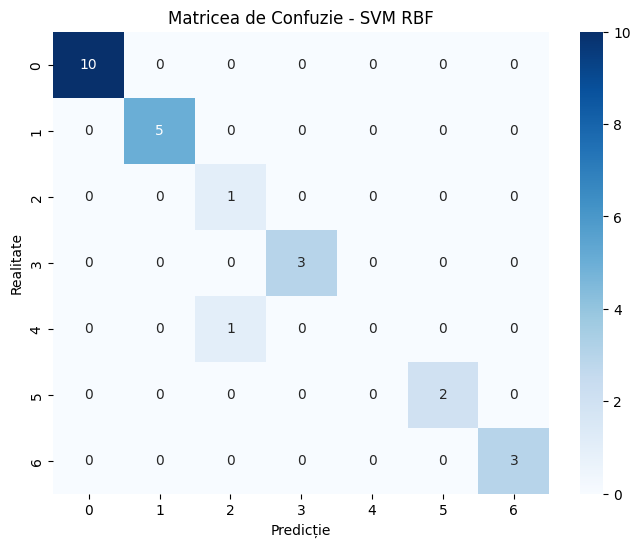

In [10]:
from sklearn.metrics import confusion_matrix

# Calculating the confusion matrix
cm = confusion_matrix(y_test, predictie_scaled)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - SVM RBF')
plt.show()

**Investigate what animals are misclassified and why**

In [11]:
# Check what animal was incorectly clasified
for index in range(len(y_test)):
  if y_test.iloc[index] != predictie_scaled[index]:
        # Get the actual index label from y_test
        original_animal_index = y_test.index[index]
        print(f"Predicted: {predictie_scaled[index]}, Real: {y_test.iloc[index]}")
        print(f"Predicted class: {classes.iloc[predictie_scaled[index]-1]['Class_Type']}, Real class: {classes.iloc[y_test.iloc[index]-1]['Class_Type']}")
        print(f"Animal:")
        display(zoo_cleaned.loc[original_animal_index].to_frame().T)

Predicted: 3, Real: 5
Predicted class: Reptile, Real class: Amphibian
Animal:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5


So the algorithm incorrectly labeled "newt" as reptile although it is an amphibian. Now, we check to see why that may be the case by checking the features associated with this classes

In [12]:
# Check the elements from class Reptile to see what features may confuse the algorithm
for index in zoo_cleaned.index:
  if zoo_cleaned.loc[index]['class_type'] == 3:
    display(zoo_cleaned.loc[index].to_frame().T)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
61,pitviper,0,0,1,0,0,0,1,1,1,1,1,0,0,1,0,0,3


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
75,seasnake,0,0,0,0,0,1,1,1,1,0,1,0,0,1,0,0,3


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
79,slowworm,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,3


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
89,tortoise,0,0,1,0,0,0,0,0,1,1,0,0,4,1,0,1,3


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
90,tuatara,0,0,1,0,0,0,1,1,1,1,0,0,4,1,0,0,3


In [13]:
# Now check the elements from class Amphibian
for index in zoo_cleaned.index:
  if zoo_cleaned.loc[index]['class_type'] == 5:
    display(zoo_cleaned.loc[index].to_frame().T)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
25,frog,0,0,1,0,0,1,1,1,1,1,0,0,4,0,0,0,5


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
88,toad,0,0,1,0,0,1,0,1,1,1,0,0,4,0,0,0,5


We can observe that the features of tuatara are almost identical to the features of newt. Only difference being the feature for aquatic. This may be a possible reason for the mislabeling, besides the small dataset disponible for those 2 classes.

In [14]:
# Check if "tuatara is part of the training set"
for original_animal_index in X_train.index:
  if zoo_cleaned.loc[original_animal_index]['animal_name'] == 'tuatara':
         display(zoo_cleaned.loc[original_animal_index].to_frame().T)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
90,tuatara,0,0,1,0,0,0,1,1,1,1,0,0,4,1,0,0,3


Since the animal "tuatara" is indeed part of the training set, and there are only 2 animals to learn from the class Amphibian. It is clear that this small difference misled the model.

# Checking the original data that contains duplicates

**Method 3: Unscaled data with duplicates**

Training set size: 75
Testing set size: 26
Accuracy: 96.15%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         5
           3       0.00      0.00      0.00         1
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.96        26
   macro avg       0.82      0.86      0.84        26
weighted avg       0.93      0.96      0.95        26



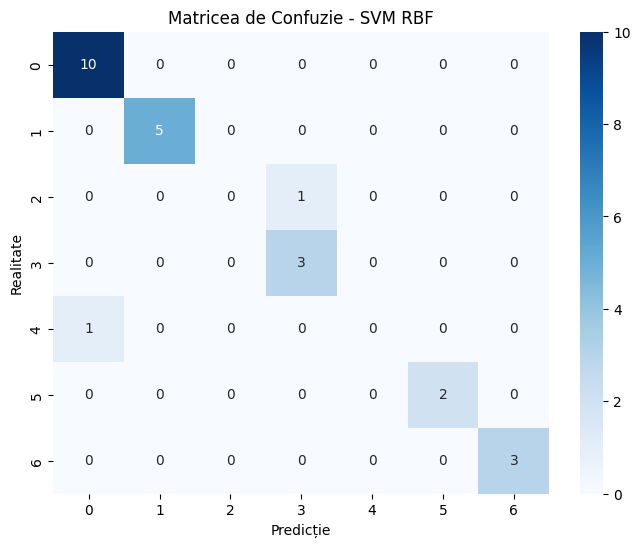

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_original = zoo.drop(columns=['animal_name', 'class_type'])
y_original = zoo['class_type']

# Separate data in training and test sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_original, y_original, test_size=0.25, random_state=42, stratify=y_original)

print(f"Training set size: {X_train2.shape[0]}")
print(f"Testing set size: {X_test2.shape[0]}")

# Applying the algorithm

clf2=svm.SVC(kernel='rbf',C=1,gamma='scale')
clf2.fit(X_train2,y_train2)
predictie_unscaled2=clf2.predict(X_test2)

# See the results
print(f"Accuracy: {accuracy_score(y_test2, predictie_unscaled2) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test2, predictie_unscaled2, zero_division=0))

# Calculating the confusion matrix
cm = confusion_matrix(y_test, predictie_unscaled)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - SVM RBF')
plt.show()

**Method 4: Scaled data with duplicates**

Training set size: 75
Testing set size: 26
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



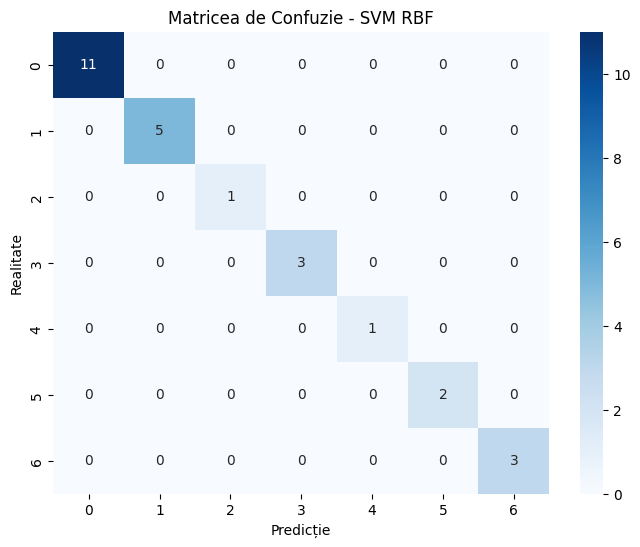

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

X_original = zoo.drop(columns=['animal_name', 'class_type'])
y_original = zoo['class_type']

# Separate data in training and test sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_original, y_original, test_size=0.25, random_state=42, stratify=y_original)

print(f"Training set size: {X_train2.shape[0]}")
print(f"Testing set size: {X_test2.shape[0]}")

# Scale the data because the number of legs can confuse the algorithm being higher than the data in other columns
sc = StandardScaler()
X_train_scaled2= sc.fit_transform(X_train2)
X_test_scaled2 = sc.transform(X_test2)

# Applying the algorithm

clf3=svm.SVC(kernel='rbf',C=1,gamma='scale')
clf3.fit(X_train_scaled2,y_train2)
predictie_scaled2=clf3.predict(X_test_scaled2)

# See the results
print(f"Accuracy: {accuracy_score(y_test2, predictie_scaled2) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test2, predictie_scaled2, zero_division=0))

# Calculating the confusion matrix
cm = confusion_matrix(y_test2, predictie_scaled2)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - SVM RBF')
plt.show()

Check what is the value found by "gamma='scale' " that resulted in the model to reach 100% accuracy.

In [17]:
n_features = X_train_scaled2.shape[1]
variance_X_train_scaled = X_train_scaled2.var()
gamma_value = 1 / (n_features * variance_X_train_scaled)

print(f"The calculated gamma value when gamma='scale' for the 100% accuracy model was: {gamma_value}")

The calculated gamma value when gamma='scale' for the 100% accuracy model was: 0.0625


# Hyperparameters testing

In the second phase of this project we will check what are the best hyperparameters for this model with GridSearchCV. We will check all combinations between C (from 2^(-5) to 2^7) and gamma (from 2^(-15) to 2^3), in total 247 combinations to find the best values for this model. We will test all 4 cases studied previously with *gamma='scale'*.


--- Running GridSearchCV for: Unscaled data without duplicates ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Cel mai bun C: 2
Cel mai bun Gamma: 0.25


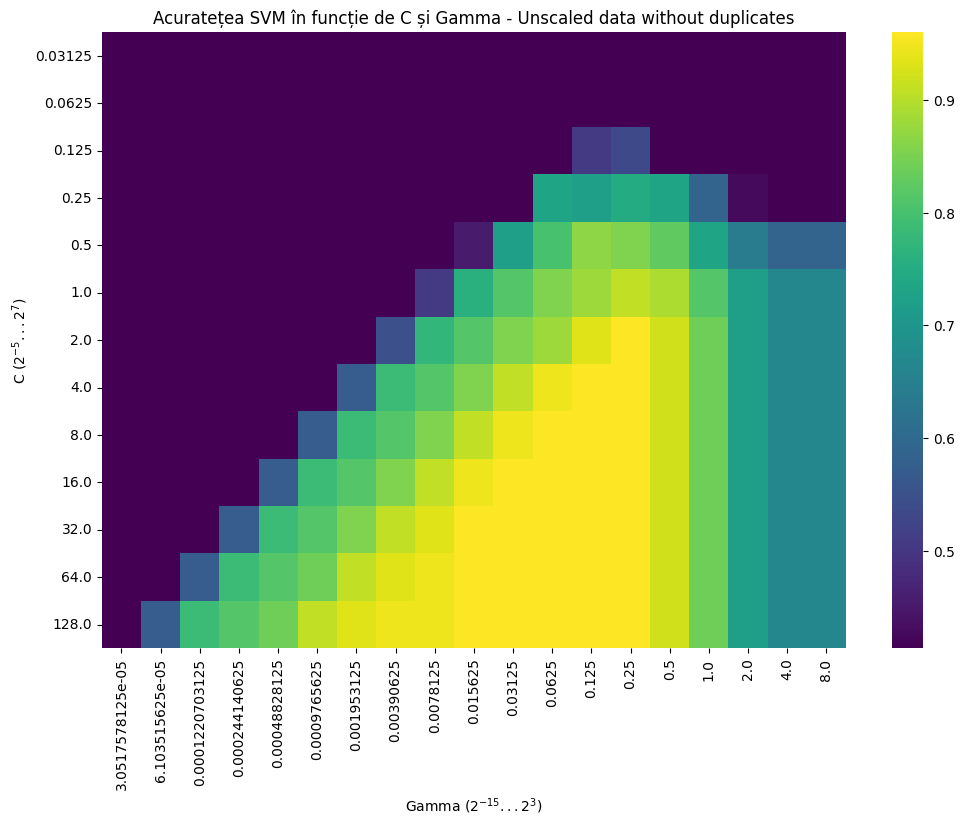


--- Running GridSearchCV for: Scaled data without duplicates ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Cel mai bun C: 4
Cel mai bun Gamma: 0.015625


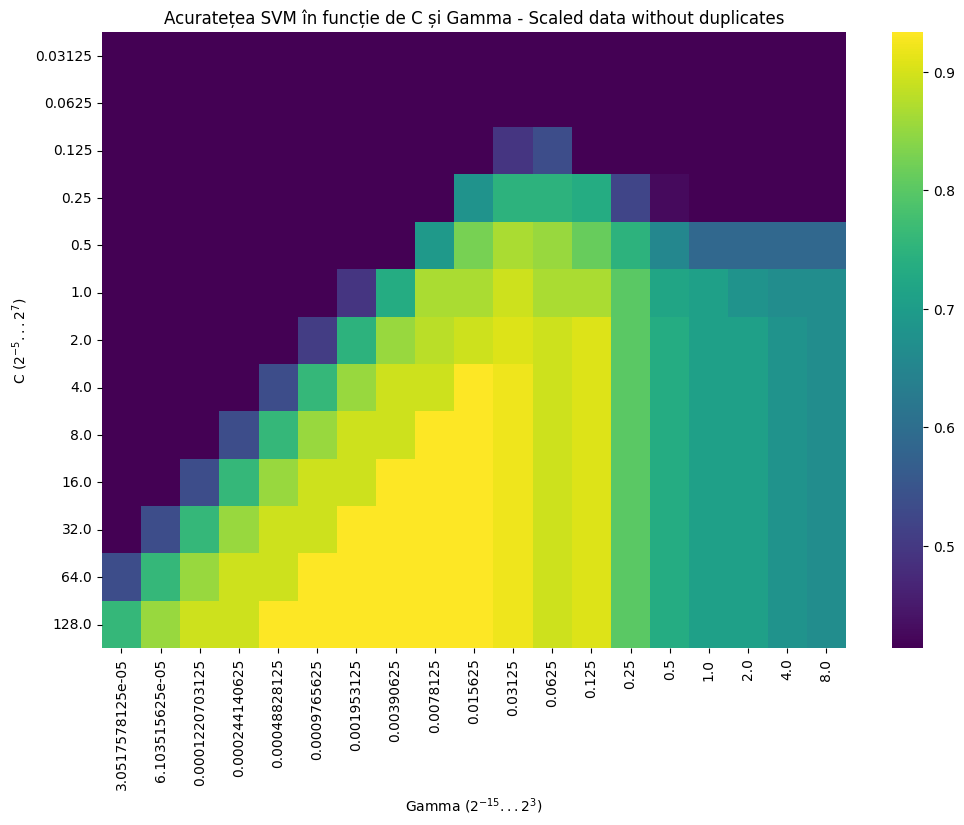


--- Running GridSearchCV for: Unscaled data with duplicates ---
Cel mai bun C: 4
Cel mai bun Gamma: 0.125


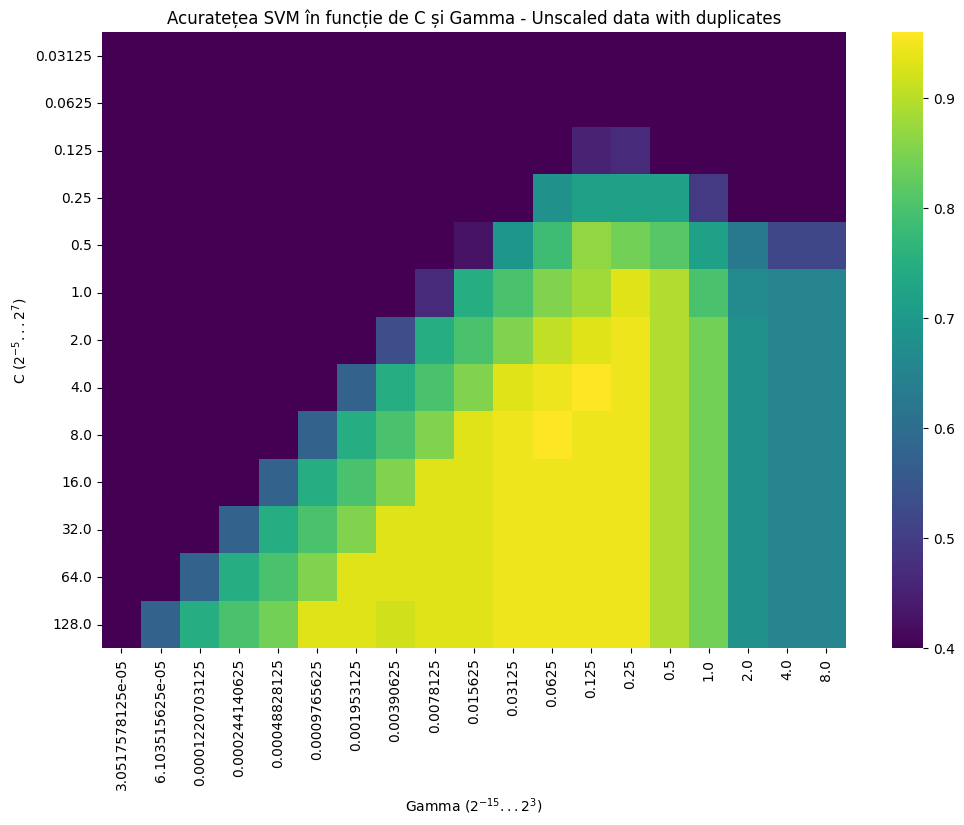


--- Running GridSearchCV for: Scaled data with duplicates ---
Cel mai bun C: 2
Cel mai bun Gamma: 0.03125


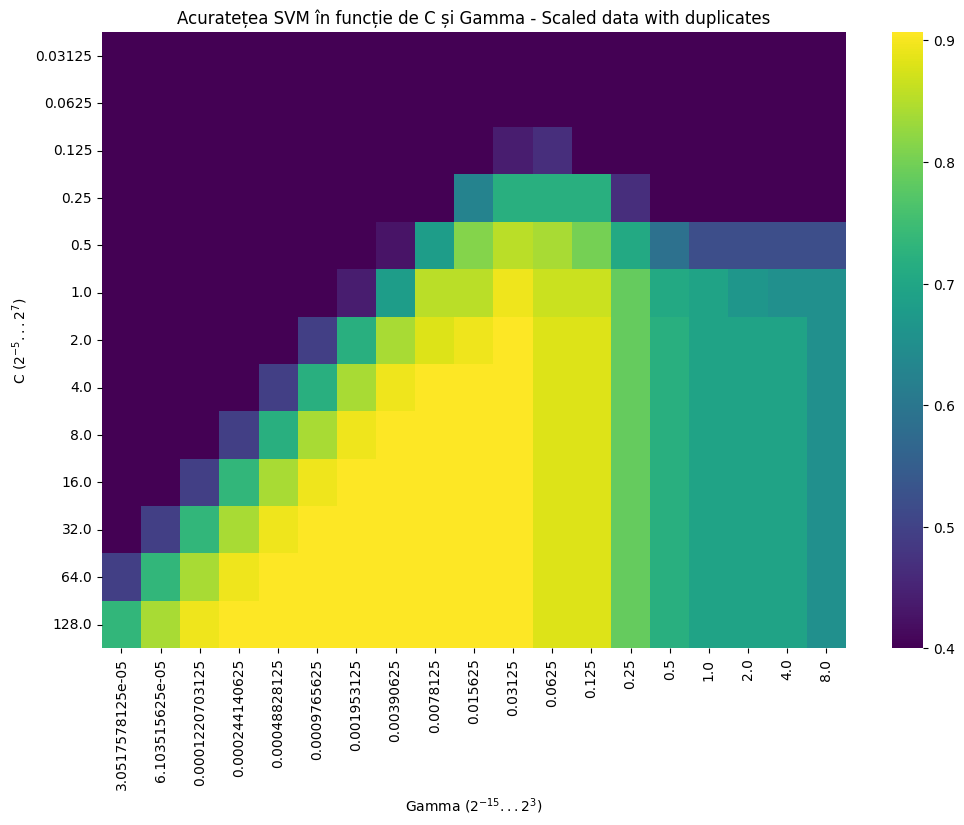

In [18]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import svm # Ensure svm is imported here for the GridSearchCV

# Define the datasets and their labels for iteration
# Now including X_test and y_test for each case
data_cases_full = [
    (X_train, y_train, X_test, y_test, "Unscaled data without duplicates"),
    (X_train_scaled, y_train, X_test_scaled, y_test, "Scaled data without duplicates"),
    (X_train2, y_train2, X_test2, y_test2, "Unscaled data with duplicates"),
    (X_train_scaled2, y_train2, X_test_scaled2, y_test2, "Scaled data with duplicates")
]

# Define the parameter grid
c_range = [2**i for i in range(-5, 8)]
gamma_range = [2**i for i in range(-15, 4)]
param_grid = { 'C': c_range, 'gamma': gamma_range,'kernel': ['rbf']}

# List to store best estimators and corresponding test data for later evaluation
all_best_models_info = []

# Loop through each data case
for i, (X_data, y_data, X_test_case, y_test_case, title_suffix) in enumerate(data_cases_full):
    print(f"\n--- Running GridSearchCV for: {title_suffix} ---")

    # Initialize and fit GridSearchCV
    # Using verbose=0 to reduce output verbosity for cleaner loop output
    # Setting cv=3 to avoid warnings about too few members in some classes for n_splits=5
    # For a final model, n_splits=5 or more would be preferred if class support allows.
    grid = GridSearchCV(svm.SVC(), param_grid, refit=True, verbose=0, cv=3)
    grid.fit(X_data, y_data)

    print(f"Cel mai bun C: {grid.best_params_['C']}")
    print(f"Cel mai bun Gamma: {grid.best_params_['gamma']}")

    # Store the best estimator and its associated test data and title
    all_best_models_info.append({
        'title': title_suffix,
        'best_estimator': grid.best_estimator_,
        'X_test': X_test_case,
        'y_test': y_test_case
    })

    # Visualize the mean accuracy for each hyperparameters combination
    results_df = pd.DataFrame(grid.cv_results_)
    viz_data = results_df.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

    # Draw the Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(viz_data, annot=False, cmap='viridis')
    plt.title(f'Acuratețea SVM în funcție de C și Gamma - {title_suffix}')
    plt.xlabel('Gamma ($2^{-15} ... 2^3$)')
    plt.ylabel('C ($2^{-5} ... 2^7$)')
    plt.show()

### Evaluating the model with the best hyperparameters from GridSearchCV

This section iterates through the best models identified by GridSearchCV for each of the four data preprocessing cases. For each model, it calculates the accuracy, prints a detailed classification report, and visualizes the confusion matrix. This provides a clear comparison of how different data handling strategies (unscaled/scaled, with/without duplicates) impact the SVM's performance with optimized hyperparameters.


 Evaluating Best Models for Each Case

 Results for: Unscaled data without duplicates
Accuracy: 96.00%
Best C: 2, Best Gamma: 0.25

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         5
           3       0.50      1.00      0.67         1
           4       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.96        25
   macro avg       0.79      0.86      0.81        25
weighted avg       0.94      0.96      0.95        25



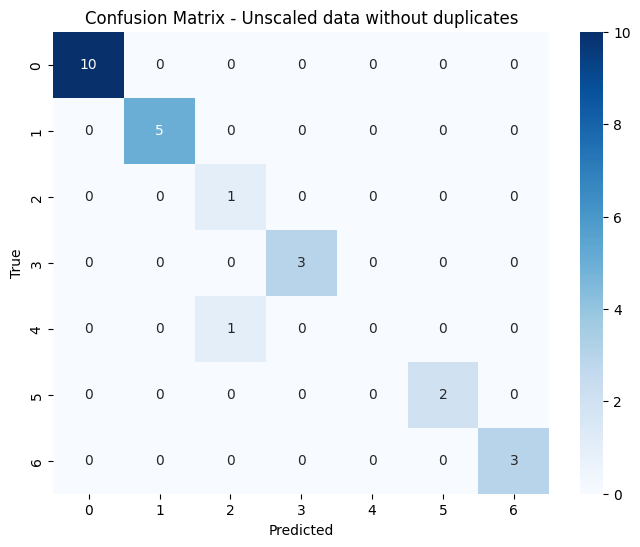


 Results for: Scaled data without duplicates
Accuracy: 96.00%
Best C: 4, Best Gamma: 0.015625

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         5
           3       0.50      1.00      0.67         1
           4       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.96        25
   macro avg       0.79      0.86      0.81        25
weighted avg       0.94      0.96      0.95        25



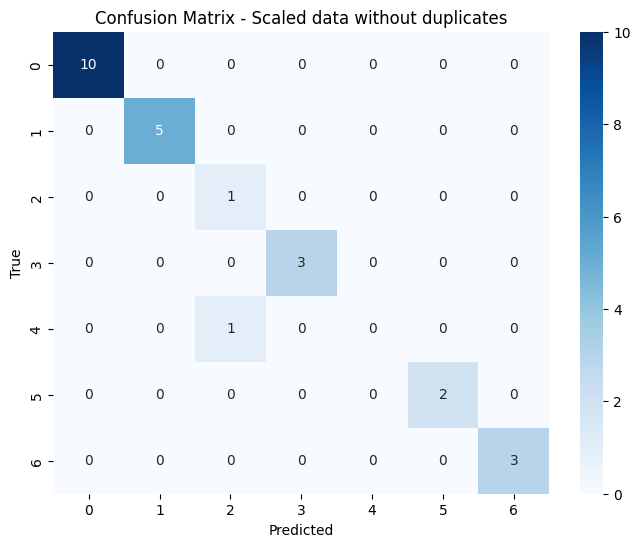


 Results for: Unscaled data with duplicates
Accuracy: 100.00%
Best C: 4, Best Gamma: 0.125

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



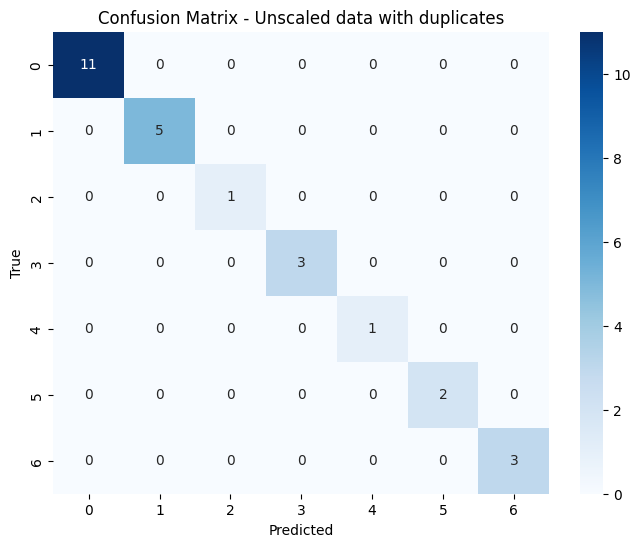


 Results for: Scaled data with duplicates
Accuracy: 100.00%
Best C: 2, Best Gamma: 0.03125

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



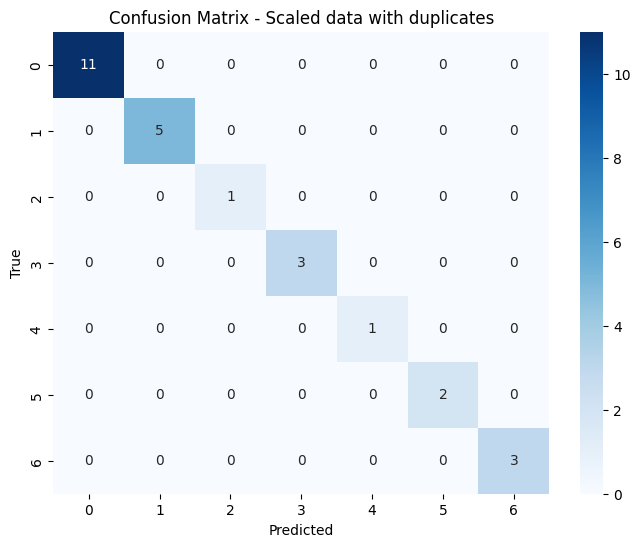

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n Evaluating Best Models for Each Case")

for model_info in all_best_models_info:
    title = model_info['title']
    best_estimator = model_info['best_estimator']
    X_test_case = model_info['X_test']
    y_test_case = model_info['y_test']

    print(f"\n Results for: {title}")

    # Predict on the test set using the best estimator
    y_pred = best_estimator.predict(X_test_case)

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test_case, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Best C: {best_estimator.C}, Best Gamma: {best_estimator.gamma}")

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test_case, y_pred, zero_division=0))

    # Calculate and plot confusion matrix
    cm = confusion_matrix(y_test_case, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {title}')
    plt.show()

### Investigating Misclassified Animals in Cases Without Duplicates

This section delves into the specific animals that were misclassified by the best models for the 'Unscaled data without duplicates' and 'Scaled data without duplicates' cases. It prints the predicted and actual classes, along with the full features of the misclassified animal from the `zoo_cleaned` dataset, to understand the nature of the errors.

In [20]:
# Loop through the first two models (cases without duplicates)
for i in range(2):
    model_info = all_best_models_info[i]
    title = model_info['title']
    best_estimator = model_info['best_estimator']
    X_test_case = model_info['X_test']
    y_test_case = model_info['y_test']

    print(f"\n--- Misclassified Animals for: {title} ---")

    y_pred = best_estimator.predict(X_test_case)

    misclassified_count = 0
    for index in range(len(y_test_case)):
        if y_test_case.iloc[index] != y_pred[index]:
            misclassified_count += 1
            original_animal_index = y_test_case.index[index]
            print(f"Predicted Class: {classes.iloc[y_pred[index]-1]['Class_Type']} (ID: {y_pred[index]}), Real Class: {classes.iloc[y_test_case.iloc[index]-1]['Class_Type']} (ID: {y_test_case.iloc[index]})")
            print(f"Animal:")
            display(zoo_cleaned.loc[original_animal_index].to_frame().T)
    if misclassified_count == 0:
        print("No misclassified animals in this case.")


--- Misclassified Animals for: Unscaled data without duplicates ---
Predicted Class: Reptile (ID: 3), Real Class: Amphibian (ID: 5)
Animal:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5



--- Misclassified Animals for: Scaled data without duplicates ---
Predicted Class: Reptile (ID: 3), Real Class: Amphibian (ID: 5)
Animal:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5
